### Single Source Fit (Cas A)

In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
# from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.PointSourceResponse import PointSourceResponse

# from COSILikeNew import COSILike
from cosipy.interfaces import ThreeMLPluginInterface

from scoords import SpacecraftFrame

import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
import pandas as pd
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Line, Gaussian, StepFunction, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis
from tqdm import tqdm

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

14:11:14 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=60662;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=241650;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=197913;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=9847;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=135134;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=5715;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=367016;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=945108;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

14:11:17 WARNING   No fermitools installed                                              ]8;id=694418;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=433759;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=235573;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=611802;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=149736;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=195310;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=191986;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=195629;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
# Data directory
DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC4/')

In [3]:
psr_filename = '/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC4/data/responses/extended_source_response_Ti44_merged.h5'
psr = Histogram.open(psr_filename)


# Create binned data object for sources
data_obj = BinnedData("inputs.yaml")
data_loader_obj = BinnedData("inputs.yaml")

# Create binned data object for background
bg_obj = BinnedData("inputs.yaml")

data_obj.load_binned_data_from_hdf5('44Ti_binned_data.hdf5')
bg_obj.load_binned_data_from_hdf5('../data/backgrounds/binned/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5')


# Alternately, use source injector to create template models
# Use the same pre-computed response file with a fairly representative
# flux. For a narrow 1154-1160 keV energy bin, the exact spectral 
# shape wouldn't matter (i.e., wouldn't impart any biases in the Phi,
# PsiChi axes)

In [4]:
hist = bg_obj.binned_data.project(['Em', 'Phi', 'PsiChi']).todense()

new_axes = []

for axis in hist.axes[:2]:
    new_axes += [Axis(axis.edges, label = axis.label,
                    scale = axis.axis_scale)]

axis = hist.axes[2]
new_axes += [HealpixAxis(edges=np.array(axis),
                         nside=axis.nside,
                         label=axis.label,
                         scheme=axis.scheme,
                         coordsys=axis.coordsys)]

new_bg = Histogram(new_axes,
                           contents = np.random.poisson(hist.contents),
                           sparse=hist.is_sparse,
                           unit=hist.unit)

In [5]:
from cosipy.spacecraftfile import SpacecraftHistory

sc_orientation = SpacecraftHistory.open(DATA_DIR.parent / "DC3/data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori")

In [6]:
from cosipy.data_io import EmCDSBinnedData
from cosipy.background_estimation import FreeNormBinnedBackground

tiny = 1e-12

bg = bg_obj.binned_data.project('Em', 'Phi', 'PsiChi')
# bg = new_bg
bkg = FreeNormBinnedBackground(bg + tiny,
                               sc_history=sc_orientation,
                               copy = False)

data = EmCDSBinnedData(data_obj.binned_data.project('Em', 'Phi', 'PsiChi'))     # Need all 3 months data to use with pre-computed response and background


WARNING RuntimeWarning: divide by zero encountered in divide



In [4]:
from cosipy.response import PointSourceResponse, ExtendedSourceResponse, BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.statistics import PoissonLikelihood

esr = ExtendedSourceResponse.open(psr_filename)

class FixedPSRWrapper:
    def __init__(self, psr):
        self._psr = psr
        self._source = None

    @property
    def axes(self):
        # BinnedThreeMLModelFolding uses this to validate axes
        return self._psr.measurement_axes  # ('Em','Phi','PsiChi') axes

    def copy(self):
        # safe copy for multiple sources
        return FixedPSRWrapper(self._psr)

    def set_source(self, source):
        # optional: you can enforce it’s a PointSource, store it
        self._source = source

    def expectation(self, copy=True):
        if self._source is None:
            raise RuntimeError("Call set_source() first.")
        h = self._psr.get_expectation(self._source.spectrum.main.shape)
        return h.copy() if copy else h

In [7]:
esr.axes.labels

array(['NuLambda', 'Ei', 'Em', 'Phi', 'PsiChi'], dtype='<U8')

In [8]:
# define the target coordinates (Cas A)
target_coord = SkyCoord.from_name('Cas A').galactic

In [9]:
import mhealpy as hp
nside = 16
idx = hp.ang2pix(nside, target_coord.l.value, target_coord.b.value, lonlat=True)
psr = PointSourceResponse(esr.axes[1:], contents=esr[idx], unit=esr.unit)

In [10]:
# Initialize the 3ML Point Source response

# Pass the 3ML Point Source response to interface implementation that will peform the 
# folding with the spectrum
response = BinnedThreeMLModelFolding(data = data, point_source_response = FixedPSRWrapper(psr))

# Likelihood to use
like_fun = PoissonLikelihood(data, response, bkg)

In [11]:
# Init 3ML plugin
cosi = ThreeMLPluginInterface('cosi',
                              like_fun,
                              response,
                              bkg)

# Init background parameters, consider as "nuisance parameters"
cosi.bkg_parameter['bkg_norm'] = Parameter('bkg_norm',  # background parameter
                                    1,  # initial value of parameter
                                    min_value=0.008,  # minimum value of parameter
                                    max_value=1.2,  # maximum value of parameter
                                    delta=0.05,  # initial step used by fitting engine
                                    unit = u.Hz,
                                    free = True
                                    )

In [12]:
F = 1e-4 * 1 / u.cm / u.cm / u.s
mu = 1157 * u.keV
sigma = 10e-1 * u.keV         # Contain the entire spread within the energy bin

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.F.max_value = F * 100
spectrum.F.min_value = F / 100
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.mu.free = False
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit
spectrum.sigma.free = False
source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = target_coord.l.value,     # Longitude (deg)
                     b = target_coord.b.value,     # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# Optional: free the position parameters
#source.position.l.free = True
#source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

In [13]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

_ = like.fit()

12:51:49 INFO      set the minimizer to minuit                                             ]8;id=275693;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=414347;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

12:51:50 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=18642;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=146546;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Gaussian.F,(1.36 +/- 0.35) x 10^-5,1 / (s cm2)
bkg_norm,(2.183 +/- 0.006) x 10^-2,Hz


Correlation matrix:

1.00,-0.35
-0.35,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,121596.23685033397
total,121596.23685033397


Values of statistical measures:

,statistical measures
AIC,243196.47376577317
BIC,243216.72255798092


In [14]:
results = like.results

# print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

# print(results.optimized_model["source"])

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=856555;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=531323;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=296803;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=450073;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

In [15]:
F_inj = 4.76e-5 * 1 / u.cm / u.cm / u.s

spectrum_inj = StepFunction()
spectrum_inj.value.value = F_inj.value
spectrum_inj.value.unit = F_inj.unit
spectrum_inj.lower_bound.value = 1154
spectrum_inj.lower_bound.unit = u.keV
spectrum_inj.upper_bound.value = 1160
spectrum_inj.upper_bound.unit = u.keV

In [16]:
results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)(1157)

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=920526;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=162681;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

equal-tail: (5.5 -1.3 +1.4) x 10^-6, hpd: (5.5 -1.2 +1.5) x 10^-6

In [17]:
energy_edges = bg.axes['Em'].edges.value #* u.keV
energy_centers = (energy_edges[:-1] + energy_edges[1:]) / 2

flux_lo = np.zeros_like(energy_centers)
flux_median = np.zeros_like(energy_centers)
flux_hi = np.zeros_like(energy_centers)
flux_inj = np.zeros_like(energy_centers)

for i, e in enumerate(energy_centers):
    flux = results_err(e)       # ph / cm^2 / s     (Gaussian flux)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.highest_posterior_density_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)       # ph / cm^2 / s

expectation = response.expectation()

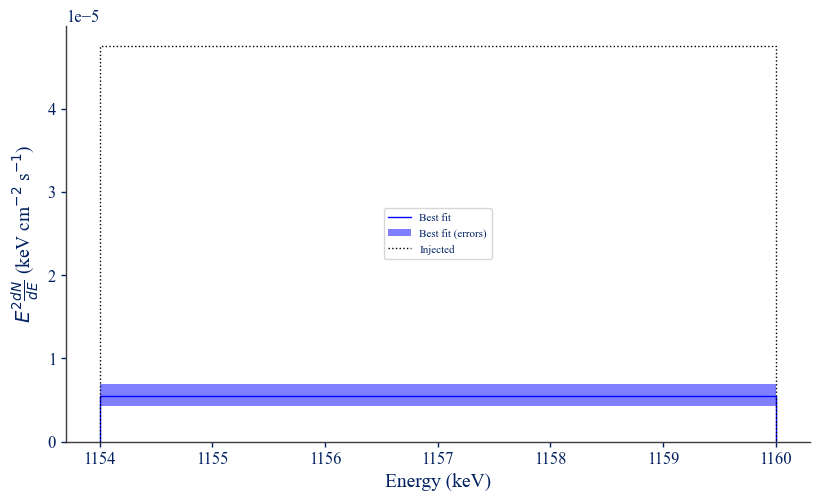

In [18]:
fig, ax = plt.subplots()

energy_widths = np.diff(energy_edges)
ax.stairs(flux_median, energy_edges, label="Best fit")
ax.fill_between(energy_edges, [flux_lo[0], flux_lo[-1]], [flux_hi[0], flux_hi[-1]], alpha=0.5, label="Best fit (errors)")
ax.stairs(flux_inj, energy_edges, color="black", linestyle=":", label="Injected")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()
plt.show()

### Stacked Analysis

In [19]:
# Stacked Analysis (multi-target; morphology / ESR path)
#
# Logical flow:
# 1) Build the same likelihood stack as elsewhere: PoissonLikelihood + ThreeML plugin.
# 2) Fold ExtendedSources through the merged `ExtendedSourceResponse` (`esr`) via
#    `BinnedThreeMLExtendedSourceResponse`.

# --- Targets to fit (5 total) ---
# Use `.galactic` so l/b are consistent with HEALPix Galactic indexing implied by `esr`.

target_coords = [
    SkyCoord.from_name('SN1987A').galactic,
    SkyCoord.from_name('Tycho').galactic,
    SkyCoord(l=4.5, b=6.8, unit='deg', frame=Galactic()),
    SkyCoord(l=266.3, b=-1.2, unit='deg', frame=Galactic()),
    SkyCoord(l=1.9, b=0.3, unit='deg', frame=Galactic()),
]

if len(target_coords) != 5:
    raise ValueError(f"Expected 5 target_coords, got {len(target_coords)}")

In [20]:
# STS defintions
target_coords = [
    SkyCoord(l=80.2, b=0.8, unit='deg', frame=Galactic()),
    SkyCoord(l=81.2, b=0.9, unit='deg', frame=Galactic()),
    SkyCoord(l=84.0, b=-1.3, unit='deg', frame=Galactic()),
    SkyCoord(l=283.8, b=75.5, unit='deg', frame=Galactic()),
    SkyCoord(l=184.6, b=-5.8, unit='deg', frame=Galactic()),
    SkyCoord(l=266.3, b=-49.7, unit='deg', frame=Galactic()),
]

In [21]:
data.data

In [22]:
sources_hist = data.data * 0
source_names = ['SN1987A', 'Tycho_3months', 'Kepler_3months', 'VelaJr_44Ti_3months', 'GS1903']
for i, name in enumerate(source_names):
    src = BinnedData('inputs.yaml')
    src.get_binned_data(f'sources/{name}_unbinned_data_filtered_with_SAAcut.fits', output_name=None)
    sources_hist = sources_hist + src.binned_data.project('Em', 'Phi', 'PsiChi')

sources_emcds = EmCDSBinnedData(sources_hist)
sources_emcds.data

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking
fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


In [23]:
STS_hist = data.data * 0
for i in range(1, 7):
    src = BinnedData('inputs.yaml')
    src.load_binned_data_from_hdf5(f'../source_injector/44Ti/STS/STS{i}.h5')
    STS_hist = STS_hist + src.binned_data.project('Em', 'Phi', 'PsiChi')

(<Mollview: >, <matplotlib.image.AxesImage at 0x457711d50>)

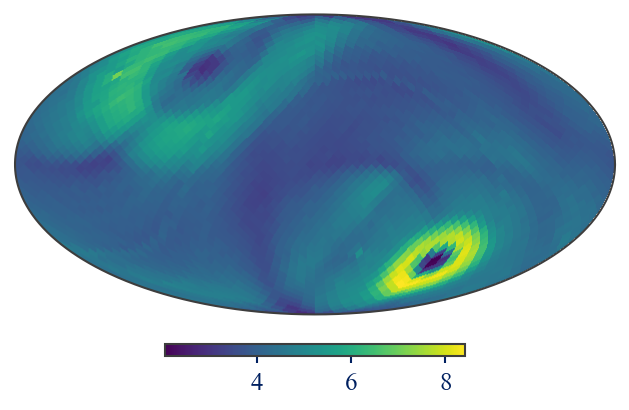

In [24]:
(src.binned_data*1000).project('PsiChi').plot()

In [25]:
data_amplified = EmCDSBinnedData(data.data + 200*STS_hist)

(<Mollview: >, <matplotlib.image.AxesImage at 0x4575efcd0>)

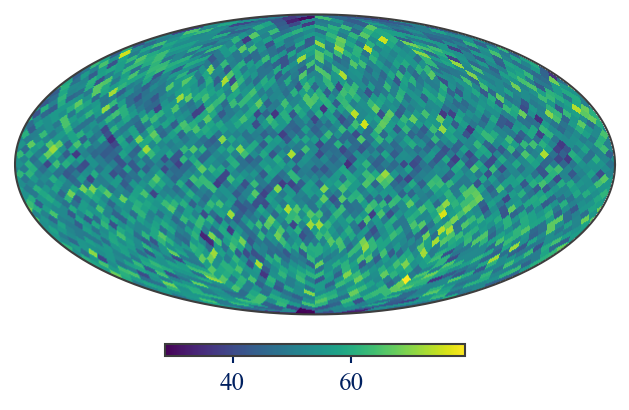

In [26]:
data_amplified.data.project('PsiChi').plot()

In [27]:
# --- Response + likelihood for stacked dataset (ExtendedSourceResponse) ---
#
# Requires `ExtendedSource` models below (narrow Gaussian_on_sphere morphology).

from cosipy.response import BinnedThreeMLExtendedSourceResponse


esr_stack = BinnedThreeMLExtendedSourceResponse(data=data_amplified, precomputed_psr=esr)

response_stack = BinnedThreeMLModelFolding(
    data=data_amplified,
    extended_source_response=esr_stack,
)

like_fun_stack = PoissonLikelihood(data_amplified, response_stack, bkg)

cosi_stack = ThreeMLPluginInterface(
    "cosi_stack",
    like_fun_stack,
    response_stack,
    bkg,
)

cosi_stack.bkg_parameter["bkg_norm"] = Parameter(
    "bkg_norm",
    1,
    min_value=0,
    max_value=100,
    delta=0.05,
    unit=u.Hz,
)

1000 km/s => 1-sigma= 3.85 keV

4000 km/s => 1-sigma= 15.4 keV

Within 1157 +/- 3 keV (~0.2-sigma), only 16% of flux

In [ ]:
# --- Define sources (narrow extended morphology approximating a point source) ---

from copy import deepcopy

from astromodels import ExtendedSource, Gaussian_on_sphere

F0 = 1e-5 * 0.16 * 1 / u.cm / u.cm / u.s        # 1e-5 typical source, 16% of flux within +/- 3 keV
mu0 = 1157 * u.keV
sigma0 = 3.85e-1 * u.keV  # contain the entire spread within the energy bin

base_spec = Gaussian()
base_spec.F.value = F0.value
base_spec.F.unit = F0.unit
base_spec.F.max_value = (F0 * 1000).value
base_spec.F.min_value = (F0 / 10).value
base_spec.mu.value = mu0.value
base_spec.mu.unit = mu0.unit
base_spec.mu.free = False
base_spec.sigma.value = sigma0.value
base_spec.sigma.unit = sigma0.unit
base_spec.sigma.free = False

# HEALPix-limited surrogate for a delta on the sphere: tweak if it needs to be smaller/tighter.
MORPH_SIGMA_DEG = 0.25      # hp.nside2pixarea(16, degrees=True) = 13 sq deg. 0.25 deg will be contained within the pixel.

extended_sources = []

for i, c in enumerate(target_coords):
    spec_i = deepcopy(base_spec)

    morph = Gaussian_on_sphere(lon0=c.l.deg, lat0=c.b.deg, sigma=MORPH_SIGMA_DEG)
    morph.lon0.free = False
    morph.lat0.free = False
    morph.sigma.free = False

    src = ExtendedSource(
        f"src_{i}",
        spectral_shape=spec_i,
        spatial_shape=morph,
    )
    extended_sources.append(src) 

In [29]:
# target_coord = SkyCoord.from_name('Cas A').galactic
morph = Gaussian_on_sphere(lon0=target_coord.l.deg, lat0=target_coord.b.deg, sigma=MORPH_SIGMA_DEG)
morph.lon0.free = False
morph.lat0.free = False
morph.sigma.free = False

CasA = ExtendedSource("CasA",
                     spectral_shape=deepcopy(spectrum),
                     spatial_shape=morph)

12:51:51 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=187194;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=518511;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

In [30]:
# --- Build the model and link fluxes across all 5 sources ---

all_sources = extended_sources + [CasA]
model_stack = Model(*all_sources)

# Fit one common flux parameter shared by all targets (like a stacked/average flux)
for i in range(len(extended_sources)-1):
    model_stack.link(
        getattr(model_stack, extended_sources[i].name).spectrum.main.Gaussian.F,
        getattr(model_stack, extended_sources[i+1].name).spectrum.main.Gaussian.F,
    )

model_stack

Model summary:
==============

                  N
Point sources     0
Extended sources  7
Particle sources  0

Free parameters (2):
--------------------

                                   value min_value max_value      unit
src_5.spectrum.main.Gaussian.F  0.000002       0.0    0.0016  s-1 cm-2
CasA.spectrum.main.Gaussian.F   0.000014  0.000001      0.01  s-1 cm-2

Fixed parameters (45):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (5):
----------------------

               src_0.spectrum.main.Gaussian.F
linked to      src_1.spectrum.main.Gaussian.F
function                                 Line
current value                        0.000002
unit                              1 / (s cm2)

               src_1.spectrum.main.Gaussian.F
linked to      src_2.spectrum.main.Gaussian.F
function                                 Line
current value                        0.000002
unit                              1 / (s cm2)

               src_2.spectrum.main.Gaussian.F
linked to      src_3.spectrum.main.Gaussian.F
function                                 Line
current value                        0.000002
unit                              1 / (s cm2)

               src_3.spectrum.main.Gaussian.F
linked to      src_4.spectrum.main.Gaussian.F
function                                 Line
current value                        0.000002
unit                              1 / (s cm2)

               src_4.spectrum.main.Gaussian.F
linked to      src_5.spectrum.main.Gaussian.F
function                                 Line
current value                        0.000002
unit                              1 / (s cm2)


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [31]:
# --- Fit ---
jl_stack = JointLikelihood(model_stack, DataList(cosi_stack))
fit_results_stack = jl_stack.fit()

fit_results_stack

12:51:51 INFO      set the minimizer to minuit                                             ]8;id=256882;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=898204;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

12:51:57 WARNING   97.04 percent of samples have been thrown away because they failed the  ]8;id=25820;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=232090;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

12:51:57 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=920816;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=40012;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=384103;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=176206;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=209271;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=967858;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_stack,124951.76859470346
total,124951.76859470346


Values of statistical measures:

,statistical measures
AIC,249909.53731961807
BIC,249939.91047537638


(                                   value  negative_error  positive_error  \
 src_5.spectrum.main.Gaussian.F  0.001413       -0.001061       -0.000061   
 CasA.spectrum.main.Gaussian.F   0.000347       -0.000019        0.000017   
 bkg_norm                        0.024665       -0.000064        0.000066   
 
                                    error         unit  
 src_5.spectrum.main.Gaussian.F  0.000500  1 / (s cm2)  
 CasA.spectrum.main.Gaussian.F   0.000018  1 / (s cm2)  
 bkg_norm                        0.000065           Hz  ,
               -log(likelihood)
 cosi_stack  124951.76859470346
 total       124951.76859470346)

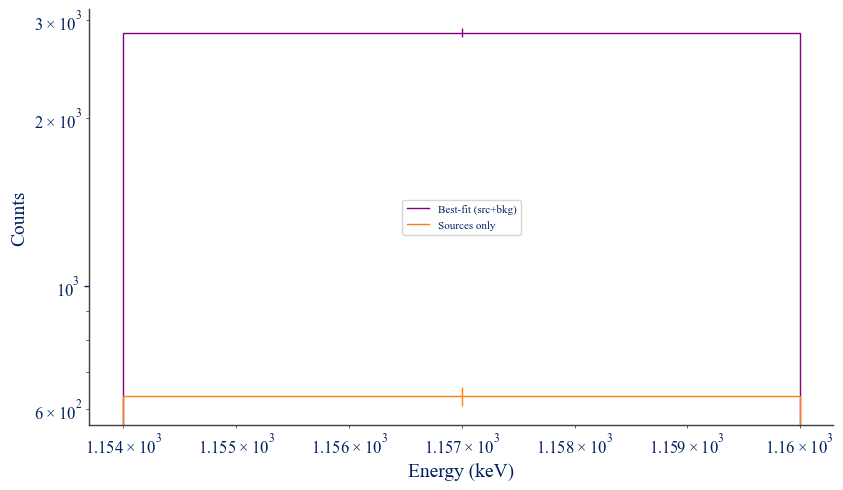

In [32]:
# --- Plot folded model vs stacked data (projection on Em) ---

total_expectation = response_stack.expectation(data_amplified)

energy_edges = data_amplified.axes['Em'].edges.value
energy_centers = data_amplified.axes['Em'].centers.value

# sources_expectation = esr_stack.expectation(sources_emcds)
bkg_expectation = bkg.expectation(copy=True)

# total_with_bkg = sources_expectation + bkg_expectation

fig, ax = plt.subplots()

ax.stairs(total_expectation.project('Em').todense().contents, energy_edges, color='purple', label="Best-fit (src+bkg)")
ax.errorbar(energy_centers, total_expectation.project('Em').todense().contents, yerr=np.sqrt(total_expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)

# ax.stairs(data.data.project('Em').todense().contents, energy_edges, color='black', ls=":", label="Stacked data")
# ax.errorbar(energy_centers, data.data.project('Em').todense().contents, yerr=np.sqrt(data.data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.stairs(sources_hist.project('Em').todense().contents, energy_edges, color='tab:orange', label="Sources only")
ax.errorbar(energy_centers, sources_hist.project('Em').todense().contents, yerr=np.sqrt(sources_hist.project('Em').todense().contents), color='tab:orange', linewidth=0, elinewidth=1)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.set_yscale('log')
ax.set_xscale('log')
ax.legend()
plt.show()


In [33]:
# --- Deconvolved spectrum plot (linked flux across the 5 sources) ---

ref_name = extended_sources[0].name

results_stack = jl_stack.results
print(results_stack.display())

parameters = {
    par.name: results_stack.get_variates(par.path)
    for par in results_stack.optimized_model[ref_name].parameters.values()
    if par.free
}

results_stack_err = results_stack.propagate(
    results_stack.optimized_model[ref_name].spectrum.main.shape.evaluate_at,
    **parameters,
)


Best fit values:

,result,unit
parameter,,
src_5.spectrum.main.Gaussian.F,(0.1 +/- 2.4) x 10^-2,1 / (s cm2)
CasA.spectrum.main.Gaussian.F,(3.47 +/- 0.22) x 10^-4,1 / (s cm2)
bkg_norm,(2.467 +/- 0.007) x 10^-2,Hz


Correlation matrix:

1.00,-0.00,-0.00
-0.00,1.00,-0.37
-0.00,-0.37,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=620682;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=314735;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=913886;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=527062;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=764985;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=643319;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=375197;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=966654;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=197335;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=591498;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

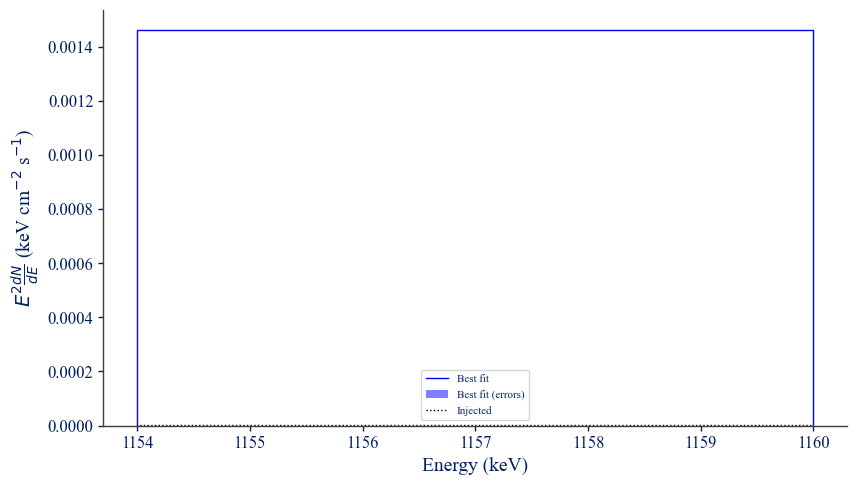

In [34]:
# Use the stacked binned energy axis
energy_edges = data_amplified.data.axes['Em'].edges.value
energy_centers = data_amplified.data.axes['Em'].centers.value

flux_lo = np.zeros_like(energy_centers)
flux_median = np.zeros_like(energy_centers)
flux_hi = np.zeros_like(energy_centers)
flux_inj_plot = np.zeros_like(energy_centers)

for i, e in enumerate(energy_centers):
    flux = results_stack_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj_plot[i] = base_spec.evaluate_at(e)

fig, ax = plt.subplots()

ax.stairs(flux_median, energy_edges, label="Best fit")
ax.fill_between(energy_centers, flux_lo, flux_hi, alpha=0.5, step="mid", label="Best fit (errors)")
ax.stairs(flux_inj_plot, energy_edges, color="black", linestyle=":", label="Injected")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

_ = ax.legend()
plt.show()

In [35]:
import healpy as hp

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=574962;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=466756;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=418399;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=835718;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=640385;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=479916;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=437526;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=8636;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=152574;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=588696;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

...

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=11720;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=908907;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=657006;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=831949;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=780203;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=573527;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=134573;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=572926;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=794042;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=345430;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

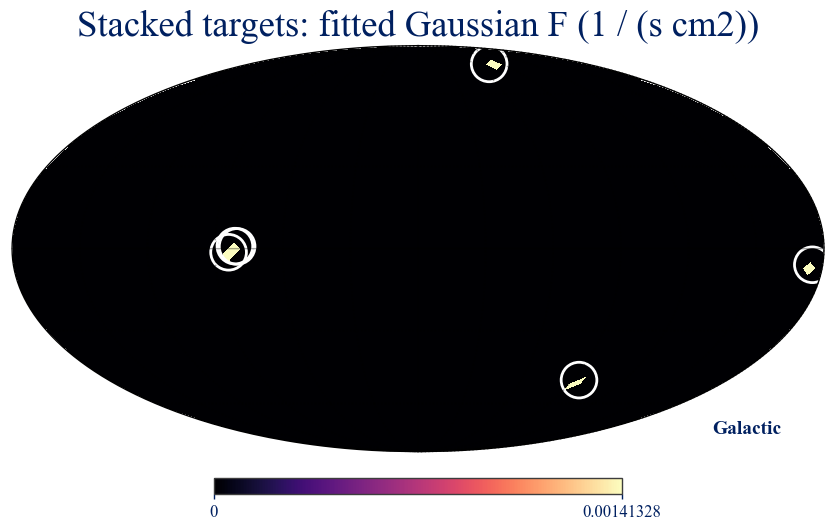

In [36]:
# --- Mollweide map of stacked targets + fitted Gaussian norms ---

# Requires: extended_sources, jl_stack (fit), esr (merged ExtendedSourceResponse)

nside_plot = int(esr.axes[0].nside)

flux_unit = jl_stack.results.optimized_model[extended_sources[0].name].spectrum.main.Gaussian.F.unit


def galactic_lb_deg_from_extended_source(src):
    """
    For `Gaussian_on_sphere`, the sky location is carried by lon0/lat0 on the spatial template.
    """

    morph = src.spatial_shape
    return float(morph.lon0.value), float(morph.lat0.value)


npix = hp.nside2npix(nside_plot)
flux_map = np.zeros(npix, dtype=float)

for src in extended_sources:
    l_deg, b_deg = galactic_lb_deg_from_extended_source(src)

    ipix = hp.ang2pix(nside_plot, l_deg, b_deg, lonlat=True)

    Fpar = jl_stack.results.optimized_model[src.name].spectrum.main.Gaussian.F

    # Parameter.value is already in physical units for this spectral norm
    flux_val = float(Fpar.value)
    flux_map[ipix] = flux_val

hp.mollview(
    flux_map,
    coord="G",
    nest=False,
    title=f"Stacked targets: fitted Gaussian F ({flux_unit})",
    cmap="magma",
    norm="hist",
)

fmax = float(np.nanmax(flux_map))
if not np.isfinite(fmax) or fmax <= 0:
    fmax = 1.0

for src in extended_sources:
    Fpar = jl_stack.results.optimized_model[src.name].spectrum.main.Gaussian.F
    val = float(Fpar.value)

    l_deg, b_deg = galactic_lb_deg_from_extended_source(src)

    hp.projscatter(
        l_deg,
        b_deg,
        lonlat=True,
        coord="G",
        s=60 + 600 * (val / fmax),
        edgecolors="white",
        facecolors="none",
        linewidths=2,
        # label=f"{src.name}: {val:.3g} {Fpar.unit}",
    )

hp.graticule(dpar=30, dmer=30, alpha=0.35)
# plt.legend(loc="upper right", fontsize=10, frameon=False)
plt.show()


#### Flux not linked method

In [37]:
# Adapted from `stacked_analysis_general.ipynb`:
# - Build a model with multiple sources
# - Do NOT link their flux parameters
# - Do NOT fit (all source fluxes fixed; background norm fixed)
# - Evaluate the (negative) log-likelihood via JointLikelihood

from copy import deepcopy
# from IPython.display import clear_output

def log_like_unlinked_fixed_flux(
    cosi_stack_unlinked,
    flux_value=1e-4,
    mu_keV=1157.0,
    sigma_keV=3.85e-1,
    morph_sigma_deg=0.25,
):

    # Fix bkg parameter so the likelihood evaluation is deterministic
    cosi_stack_unlinked.bkg_parameter["bkg_norm"].free = False

    extended_sources_unlinked = []

    for i, c in enumerate(target_coords):
        spec_i = Gaussian()
        spec_i.F.unit = 1 / u.cm / u.cm / u.s
        spec_i.F.min_value = 0
        spec_i.F.max_value = flux_value * 1e6
        spec_i.F.value = flux_value
        spec_i.F.free = False

        spec_i.mu.value = mu_keV
        spec_i.mu.unit = u.keV
        spec_i.mu.free = False

        spec_i.sigma.value = sigma_keV
        spec_i.sigma.unit = u.keV
        spec_i.sigma.free = False

        morph = Gaussian_on_sphere(lon0=c.l.deg, lat0=c.b.deg, sigma=morph_sigma_deg)
        morph.lon0.free = False
        morph.lat0.free = False
        morph.sigma.free = False

        src = ExtendedSource(
            f"src_unlinked_{i}",
            spectral_shape=spec_i,
            spatial_shape=morph,
        )
        extended_sources_unlinked.append(src)

    CasA.spectrum.main.Gaussian.F.free = False

    all_sources = extended_sources_unlinked + [CasA]
    model_unlinked = Model(*all_sources)

    # plugins_unlinked = DataList(cosi_stack_unlinked)
    # like_unlinked = JointLikelihood(model_unlinked, plugins_unlinked, verbose=False)
    # like_unlinked.fit()

    cosi_stack_unlinked.set_model(model_unlinked)
    log_L = cosi_stack_unlinked.inner_fit()

    return log_L


# Example: evaluate the likelihood for all targets at the same fixed flux
ll_fixed = log_like_unlinked_fixed_flux(deepcopy(cosi_stack), flux_value=1e-4)

# clear_output(wait=True)

print("current_minimum (unlinked, fixed flux) =", ll_fixed)

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=792069;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=160816;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=245792;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=141689;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=725231;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=902066;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=355891;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=302118;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=589336;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=266446;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

...

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=22298;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=72775;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=461799;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=724433;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=15167;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=476213;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=393079;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=523164;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

current_minimum (unlinked, fixed flux) = -124929.54576526374


         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=588342;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=285155;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=657898;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=76519;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=235748;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=701251;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=879241;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=351565;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=217679;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=778461;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

...

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=203161;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=288810;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=973779;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=161354;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0016.    ]8;id=54282;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=66582;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=907767;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=203331;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

7/7  flux=0.0001  logL=-124930


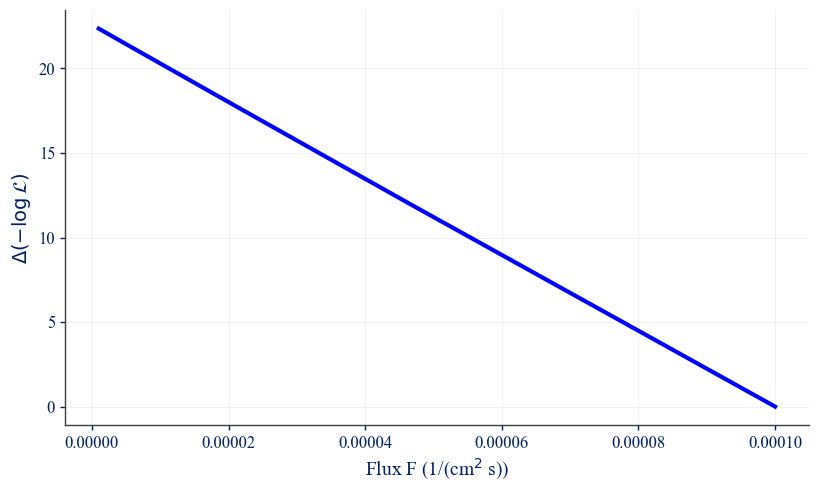

In [ ]:
# --- Likelihood scan: logL vs flux (delta steps) ---

flux_min = 1.0e-6
flux_max = 1.0e-4

flux_grid = np.geomspace(flux_min, flux_max, 7)
logL_grid = np.zeros_like(flux_grid)

for i, f in enumerate(flux_grid):
    logL_grid[i] = log_like_unlinked_fixed_flux(deepcopy(cosi_stack), flux_value=float(f))
    # clear_output(wait=True)
    print(f"{i+1}/{len(flux_grid)}  flux={f:.3g}  logL={logL_grid[i]:.6g}")

# Plot either logL or Δ(-logL)
minus_logL = -logL_grid
minus_logL0 = minus_logL - np.nanmin(minus_logL)


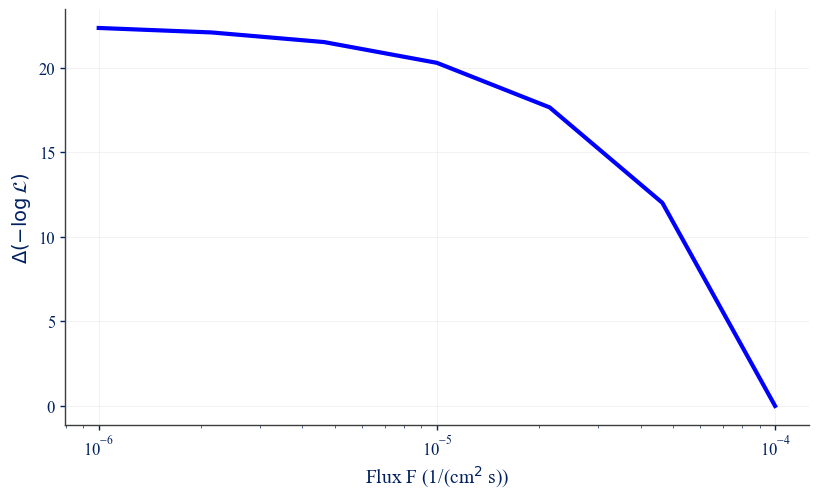

In [39]:
fig, ax = plt.subplots()
ax.plot(flux_grid, minus_logL0)
ax.set_xlabel(r"Flux F (1/(cm$^2$ s))")
ax.set_ylabel(r"$\Delta(-\log \mathcal{L})$")
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
plt.show()